# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [15]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [17]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [18]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 

- El dataset no tiene valores ausentes.
- La columna date es de tipo de dato object y debería de ser datetime.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [19]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [20]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [21]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [22]:
# Resumen estadístico
df.describe()

,converted,gasto
count,40000.00000,40000.000000
mean,0.14265,9.325554
std,0.34972,25.667986
min,0.00000,0.000000
25%,0.00000,0.000000
50%,0.00000,0.000000
75%,0.00000,0.000000
max,1.00000,303.680000


In [23]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1].describe()

,converted,gasto
count,5706.0,5706.000000
mean,1.0,65.373668
std,0.0,30.896545
min,1.0,12.120000
25%,1.0,42.950000
50%,1.0,59.860000
75%,1.0,80.370000
max,1.0,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [24]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in df.select_dtypes(include='object'):
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Conteo de categorías:

--- user_id ---
cf7a992d-b4a6-4360-b7cf-0585bcfb2483    1
6b6609a9-4375-41cb-9471-08ff3387eb08    1
c246d4e6-40a8-4c90-bdf4-ad4b23b30723    1
b1921f40-707f-4421-841d-a73689ce8524    1
87c9d309-511a-4657-be9b-462dc343757e    1
                                       ..
59f5aa3f-9b8e-4e88-98b7-5907d03af67a    1
92ef35ff-e4b3-4275-bcf7-8e03bcb49ec1    1
4f2f1585-ee5a-43fe-91a2-a245a9d0e8c8    1
9f875b1b-35c2-4a66-ac4b-2bfcb8cdd176    1
b5f9ca74-52f2-4c7d-9636-6c8c481a845a    1
Name: user_id, Length: 40000, dtype: int64

--- date ---
2026-01-24    1512
2026-01-18    1504
2026-01-13    1463
2026-01-19    1462
2026-01-02    1462
2026-01-27    1461
2026-01-12    1456
2026-01-01    1455
2026-01-09    1454
2026-01-08    1452
2026-01-07    1447
2026-01-10    1447
2026-01-06    1439
2026-01-16    1438
2026-01-04    1431
2026-01-28    1423
2026-01-21    1415
2026-01-26    1405
2026-01-20    1402
2026-01-22    1399
2026-01-05    1397
2026-01-23    1396
2026-01-15    1391
2026

✍️ **Comentario**: 

- Todas las columnas tienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [25]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [26]:
# Aplicar prueba
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados

print(f"Estadístico : {t_stat:.4f}")
print(f"Valor p     : {p_value:.6f}")

Estadístico : -9.3656
Valor p     : 0.000000


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza

Dado que el valor p es extremadamente menor que el umbral común de significancia (0.05), existe evidencia estadística contundente para rechazar la hipótesis nula (H₀).

**Interpretación de negocio:**  

-Esto significa que el gasto promedio entre las versiones A y B no es igual.

-Sí existe una diferencia real y estadísticamente significativa en el valor económico generado por cada landing. 

-La diferencia en gasto no es producto del azar:
una de las dos versiones está generando mayor ingreso por usuario convertido.



---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [30]:
# Número de usuarios convertidos por página

conversiones_pag = df.groupby('landing')['converted'].sum()

# Total de usuarios por página

total_pag = df.groupby('landing')['converted'].count()

# Pasar datos a formato lista
conteos = [conversiones_pag ['A'], conversiones_pag ['B']]
num_observaciones = [total_pag ['A'], total_pag ['B']]

print("Usuarios convertidos por página:\n", conteos)
print("\nTotal de usuarios por página:\n", num_observaciones)


Usuarios convertidos por página:
 [2512, 3194]

Total de usuarios por página:
 [19982, 20018]


In [31]:
# Aplicar prueba

from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(conteos, num_observaciones)

# Visualizar resultados

print(f"Estadístico z: {z_stat}")
print(f"Valor P: {p_value}")

Estadístico z: -9.677362674655983
Valor P: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza

**Interpretación de negocio:**  

La evidencia estadística es contundente: las dos versiones se comportan de manera distinta en su capacidad para convertir usuarios.

El desempeño de conversión depende de la versión de landing.Esto significa que la elección entre A y B sí afecta directamente cuántos usuarios se convierten en clientes, por lo que vale la pena continuar con el análisis para identificar cuál versión es superior


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [33]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab( df["traffic_source"], df["converted"])

<div class="alert alert-block alert-success">
<b>Tabla de Contingencia — Trafico</b> <a class="tocSkip"></a>

Construiste correctamente la tabla de contingencia utilizando pd.crosstab(). La tabla refleja adecuadamente la relacion entre la fuente de trafico y la conversion, y es la base necesaria para aplicar el test chi-cuadrado.

</div>

In [34]:
# Aplicar prueba


chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")




Estadístico chi-cuadrado: 8.662
Valor P: 0.034


<div class="alert alert-block alert-success">
<b>Interpretacion — Trafico y Conversion</b> <a class="tocSkip"></a>

El insight extraido sobre la relacion entre la fuente de trafico y la conversion es claro. Podemos decir que hay evidencia de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechzaza

**Interpretación de negocio:**  

- No todas las fuentes de tráfico aportan usuarios con la misma probabilidad de convertirse.
- Algunas fuentes están generando usuarios de mayor calidad (más propensos a convertir).
- Esto abre la puerta a optimizar inversión, campañas o esfuerzos según la fuente que realmente aporta valor.



## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [35]:
tabla2 = pd.crosstab( df["user_type"], df["converted"])

In [36]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")



Estadístico chi-cuadrado: 0.513
Valor P: 0.474


<div class="alert alert-block alert-success">
<b>Test Estadistico — Chi-cuadrado (Tipo de Usuario)</b> <a class="tocSkip"></a>

El test chi-cuadrado fue aplicado correctamente sobre la tabla de contingencia de tipo de usuario y conversion. Reportaste los valores necesarios para sustentar la conclusion estadistica de forma adecuada.

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

No se rechaza

**Interpretación de negocio:**  

-Los distintos user_type se comportan de forma similar en términos de conversión.
-No podemos asegurar que un tipo de usuario convierta mejor o peor basándonos en estos datos.
-Cualquier diferencia que se vea, probablemente es por azar, no por un patrón real.

<div class="alert alert-block alert-success">
<b>Interpretacion — Nuevos vs. Recurrentes</b> <a class="tocSkip"></a>

Excelente! Comparaste efectivamente el comportamiento de conversion entre usuarios nuevos y recurrentes, y tradujiste los hallazgos en una conclusion con valor estrategico. 

No rechazamos la hipótesis en este caso, ya que no hay evidencia suficiente de asociación entre las variables. 

</div>

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

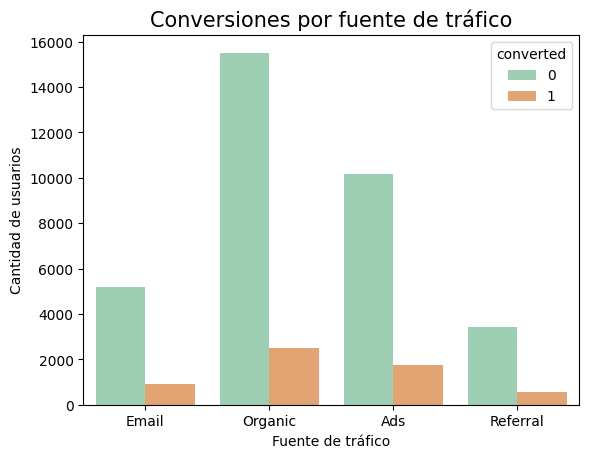

In [38]:

sns.countplot(
    data=df,
    x='traffic_source',
    hue='converted',
    palette=["#95D5B2", "#F4A261"]
)

plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.show()



✍️ **Comentario**: 

1- El volumen de usuarios varía mucho entre fuentes

-Se observa que algunas fuentes (por ejemplo, Organic o Ads) concentran un volumen mucho mayor de usuarios que otras como Email o Referral.
-Esto implica que no todas las fuentes aportan el mismo peso al funnel.

2- La cantidad de usuarios que NO convierten es mayor en todas las fuentes

-En cada categoría, la barra verde (no conversión) es más alta que la naranja (conversión).
-Esto es normal en la mayoría de funnels, pero también muestra que hay espacio para optimizar.

3- Hay diferencias visibles en la conversión entre fuentes

-Aunque todas las fuentes tienen más no‑conversión que conversión, la proporción relativa de conversiones cambia entre categorías.
-Algunas fuentes muestran una barra naranja más alta en relación con su barra verde, lo que sugiere que ciertas fuentes atraen usuarios de mayor calidad.

4- El comportamiento visual coincide con la prueba estadística

-La prueba chi‑cuadrado ya te indicó que sí existe una relación significativa entre la fuente de tráfico y la conversión.Esta gráfica lo refuerza visualmente: las fuentes no se comportan igual.


Text(0.5, 1.0, 'Tasa de conversión por fuente de tráfico')

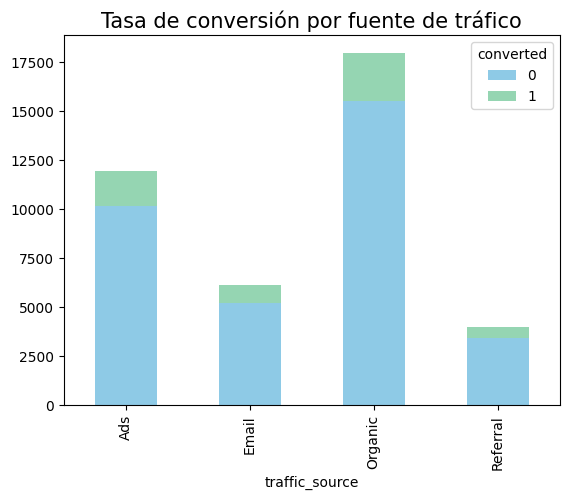

In [47]:

tabla = pd.crosstab(df['traffic_source'], df['converted'])

tabla.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)


<div class="alert alert-block alert-success">
<b>Claridad Visual</b> <a class="tocSkip"></a>

Los graficos cuentan con titulos descriptivos, ejes correctamente etiquetados y una paleta de colores adecuada. La claridad visual facilita la lectura e interpretacion de cada grafico sin necesidad de contexto adicional.

</div>

✍️ **Comentario**: 

1. Las fuentes de tráfico tienen comportamientos claramente distintos

Aunque todas muestran usuarios que convierten y no convierten, la proporción relativa cambia entre categorías. Esto confirma visualmente que la fuente de tráfico sí influye en la probabilidad de conversión.

2. Organic concentra el mayor volumen de usuarios

-La barra de Organic es la más alta, lo que indica que es la fuente que trae más tráfico total.
-Esto es importante porque una fuente con alto volumen puede tener un impacto mayor en el funnel, incluso si su tasa de conversión no es la más alta.

3. Ads también aporta un volumen considerable

   
-Aunque menor que Organic, Ads tiene un volumen relevante. Esto sugiere que es una fuente activa y con potencial para optimización, especialmente si su tasa de conversión no es tan alta como se esperaría por su costo.

4. Email y Referral tienen menor volumen

Estas fuentes aportan menos usuarios, lo cual puede significar:
- campañas más pequeñas,
- audiencias más específicas,
- o menor alcance.
Sin embargo, su efectividad debe evaluarse por proporción, no solo por volumen.

5. La proporción de conversión varía entre fuentes

En algunas fuentes, la fracción verde (no conversión) domina más que en otras.
Esto indica que ciertas fuentes atraen usuarios de mayor calidad, mientras que otras generan tráfico menos propenso a convertir


### Relación entre el tipo de usuario y la conversión

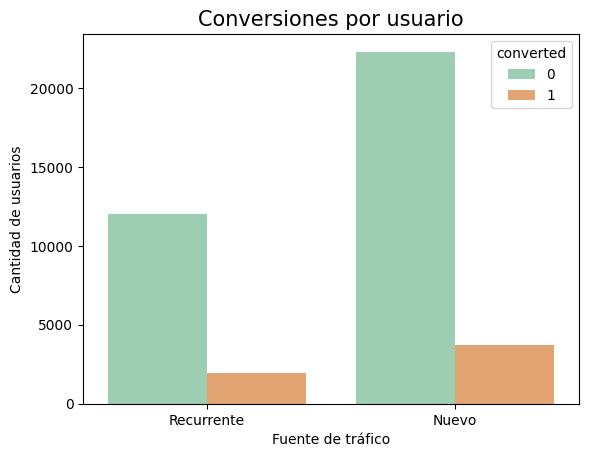

In [48]:
sns.countplot(
    data=df,
    x='user_type',
    hue='converted',
    palette=["#95D5B2", "#F4A261"]
)

plt.title('Conversiones por usuario', fontsize=15)
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.show()


✍️ **Comentario**:

1. Los usuarios nuevos representan un volumen mayor

-La barra de Nuevo es notablemente más alta que la de Recurrente, tanto en conversiones como en no conversiones.
-Esto indica que la mayor parte del tráfico proviene de usuarios nuevos.

2. La proporción de conversión es muy similar entre ambos tipos
   
-Aunque los usuarios nuevos son más en número absoluto, la relación entre quienes convierten y quienes no convierten es muy parecida en ambos grupos.
-Visualmente, las barras naranjas (conversión) mantienen una proporción similar respecto a las verdes (no conversión).

3. No se observa una diferencia clara en efectividad
   
-Ninguno de los dos tipos de usuario muestra una ventaja evidente en términos de tasa de conversión.
-Esto coincide con el resultado estadístico donde no se rechazó la hipótesis nula, indicando que user_type no influye significativamente en la conversión.

4. El comportamiento es consistente y estable
   
La similitud entre ambos grupos sugiere que el funnel funciona de manera uniforme para usuarios nuevos y recurrentes.
No hay señales de que uno de los segmentos esté respondiendo mejor o peor al proceso de conversión.


Text(0.5, 1.0, 'Tasa de conversión por usuario')

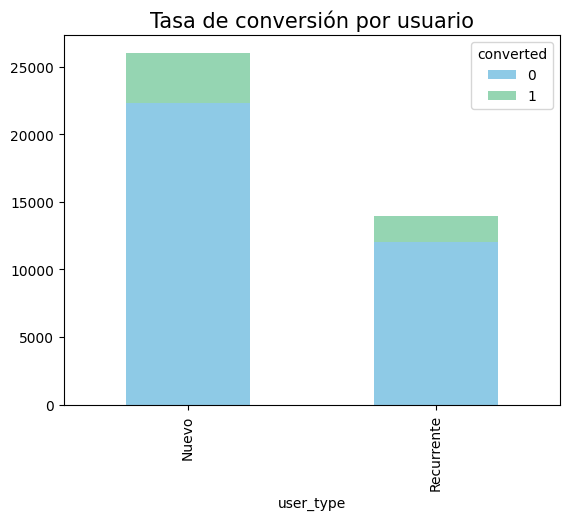

In [46]:
tabla = pd.crosstab(df['user_type'], df['converted'])

tabla.plot(kind='bar', stacked=True, color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por usuario', fontsize=15)


<div class="alert alert-block alert-success">
<b>Graficos Clave</b> <a class="tocSkip"></a>

Los graficos son claros, informativos y estan bien construidos. 

Excelente trabajo!

</div>

✍️ **Comentario**: 

1. La proporción de conversión es prácticamente igual entre usuarios nuevos y recurrentes

-Aunque los usuarios nuevos son más en volumen total, la proporción entre quienes convierten y quienes no convierten es muy similar en ambos grupos.
-Esto se ve en que la fracción verde (no conversión) y la fracción azul/verde claro (conversión) mantienen casi la misma relación en ambas barras.

2. El volumen no altera la efectividad
   
-Los usuarios nuevos aportan más tráfico, pero no convierten mejor ni peor que los recurrentes.
-Esto refuerza que el tipo de usuario no cambia la probabilidad de conversión.

3. La gráfica confirma visualmente el resultado estadístico
    
-En la prueba chi‑cuadrado obtuviste un p‑value de 0.474, lo que indicó que user_type no tiene relación significativa con la conversión.
-Esta gráfica lo respalda: no hay diferencias visibles en la tasa de conversión entre ambos grupos.

4. El comportamiento del funnel es estable entre segmentos
   
--Ambos tipos de usuario siguen un patrón muy parecido:
- mayoría no convierte,
- una proporción menor sí convierte,
- y esa proporción es casi idéntica en ambos casos.
--Esto sugiere que el funnel funciona de manera uniforme para ambos segmentos.


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- Observacion 1: La página B presenta un gasto promedio mayor entre los usuarios que convierten.
- Observacion 2: La página A muestra un gasto promedio menor y más disperso.
  
- **Interpretación:**

Los usuarios que convierten en la página B tienden a gastar más, lo que sugiere que su diseño o contenido impulsa un comportamiento de compra más valioso.

**Tasa de conversión:** 

- Observacion 1: La prueba z arrojó un valor p extremadamente pequeño (≈ 3.7e‑22), indicando una diferencia estadísticamente significativa entre A y B
- Observacion 2: La página B muestra una tasa de conversión mayor que la página A.
  
- **Interpretación:**

La página B no solo convierte más usuarios, sino que lo hace de forma consistente y estadísticamente robusta. Es la versión claramente superior.

---

#### 📊 **Segmentación por fuente de tráfico**

- Observaciones

- Las fuentes de tráfico muestran diferencias claras en volumen y proporción de conversión.
- Organic y Ads aportan la mayor cantidad de usuarios, pero su efectividad relativa varía.
- Email y Referral tienen menor volumen, pero mantienen proporciones estables.
- La prueba chi‑cuadrado (p = 0.034) confirmó que la fuente de tráfico sí influye en la conversión

- **Interpretación:**

La calidad del tráfico depende del canal. No todos los canales aportan usuarios con la misma probabilidad de convertir, por lo que la estrategia de adquisición debe priorizar los canales más efectivos, no solo los más voluminosos.

 ---

#### 📊 **Segmentación por tipo de usuario**

- Observacion:

- Los usuarios nuevos son más numerosos, pero su proporción de conversión es prácticamente igual a la de los recurrentes.
- La prueba chi‑cuadrado (p = 0.474) mostró que no hay diferencia significativa entre ambos grupos

- **Interpretación:**

El tipo de usuario (Nuevo vs. Recurrente) no afecta la probabilidad de conversión. El funnel funciona de manera uniforme para ambos segmentos.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Recomendación 1: Implementar la página B como versión definitiva, ya que maximiza tanto la conversión como el gasto promedio.
  
- Recomendación 2:  Reasignar presupuesto hacia las fuentes de tráfico con mejor rendimiento relativo, optimizando el costo por conversión.

- Recomendación 3: Mantener una estrategia de conversión uniforme para usuarios nuevos y recurrentes, ya que no existen diferencias significativas entre ellos


<div class="alert alert-block alert-success">
<b>Interpretacion de Resultados</b> <a class="tocSkip"></a>

Integraste correctamente los resultados en una interpretacion coherente y basada en evidencia. La narrativa conecta los hallazgos estadisticos con implicaciones concretas para el negocio de forma efectiva.

</div>